In [1]:
pip install protobuf

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


data = pd.read_csv("ecommerce_sales_analytics_5000.csv")
print(data)
data = data.dropna()

      order_id order_date  customer_id product_category region  quantity  \
0        10001   1/1/2022         1102           Beauty  South         7   
1        10002   1/2/2022         1435         Clothing  South         7   
2        10003   1/3/2022         1860           Beauty   East         3   
3        10004   1/4/2022         1270      Electronics   West         5   
4        10005   1/5/2022         1106         Clothing   West         5   
...        ...        ...          ...              ...    ...       ...   
4995     14996   9/5/2035         1289         Clothing   West         2   
4996     14997   9/6/2035         1294           Beauty  North         3   
4997     14998   9/7/2035         1450           Beauty   West         3   
4998     14999   9/8/2035         1903      Electronics  South         4   
4999     15000   9/9/2035         1214             Home   East         7   

      unit_price  discount payment_method  delivery_days  customer_rating  \
0         

In [6]:
target = "revenue"


X = data.drop(columns=[target])
y = data[target]


for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])


scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1568022.3750 - mae: 952.1574 - val_loss: 1186344.1250 - val_mae: 798.9886
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 369409.0312 - mae: 413.3353 - val_loss: 79300.9219 - val_mae: 218.1519
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 64100.8516 - mae: 190.3459 - val_loss: 39169.5352 - val_mae: 148.8407
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 45659.4336 - mae: 161.1158 - val_loss: 31754.7676 - val_mae: 134.8197
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40401.7188 - mae: 154.2138 - val_loss: 31410.9043 - val_mae: 135.3595
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39373.5273 - mae: 152.7678 - val_loss: 30508.2871 - val_mae: 133.7130
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 38436.1016 - mae: 152.5131 - val_loss: 29709.9453 - val_mae: 132.0641
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38290.0586 - mae: 151.171

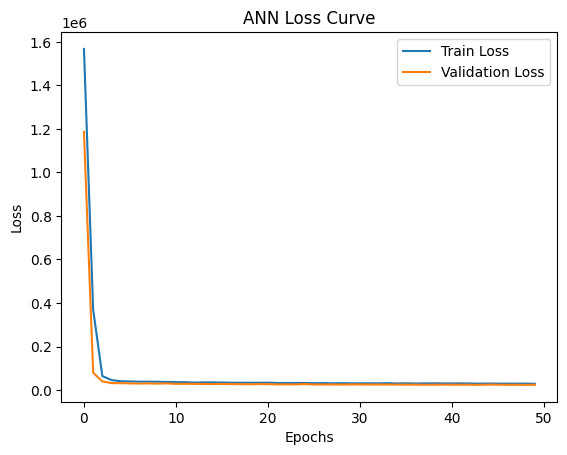

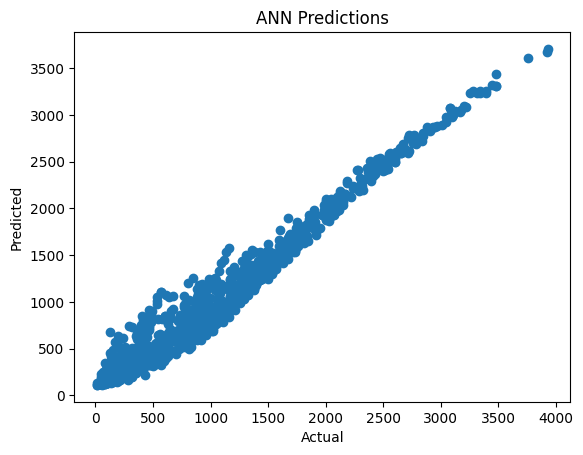

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Build ANN

ann = Sequential([
    Input(shape=(X_train.shape[1],)),   
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Train
history_ann = ann.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

# Predict
y_pred_ann = ann.predict(X_test)

# Evaluation
print("ANN MSE:", mean_squared_error(y_test, y_pred_ann))
print("ANN MAE:", mean_absolute_error(y_test, y_pred_ann))

# Plot Loss
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title("ANN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Actual vs Predicted
plt.scatter(y_test, y_pred_ann)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("ANN Predictions")
plt.show()

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1361559.5000 - mae: 873.5190 - val_loss: 648687.1250 - val_mae: 653.8401
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 567885.1875 - mae: 608.6106 - val_loss: 486624.8750 - val_mae: 549.9500
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 385610.0938 - mae: 487.6932 - val_loss: 269463.7500 - val_mae: 401.3701
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 203208.4062 - mae: 345.8015 - val_loss: 150642.1562 - val_mae: 297.4037
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 124383.7969 - mae: 271.2614 - val_loss: 103583.7422 - val_mae: 249.9917
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 87261.1016 - mae: 229.9877 - val_loss: 73830.0078 - val_mae: 214.6544
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 64716.1016 - mae: 198.6055 - val_loss: 53283.3086 - val_mae: 182.1127
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 50654.4219 - mae: 

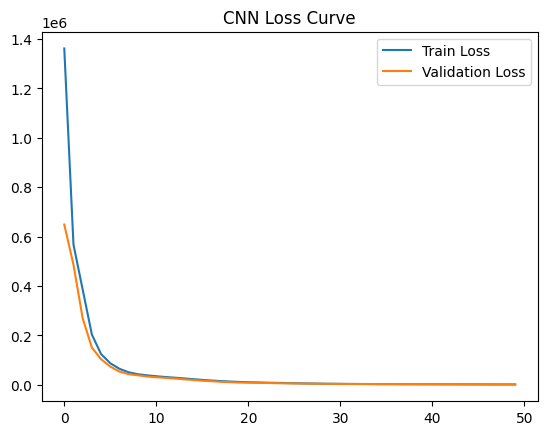

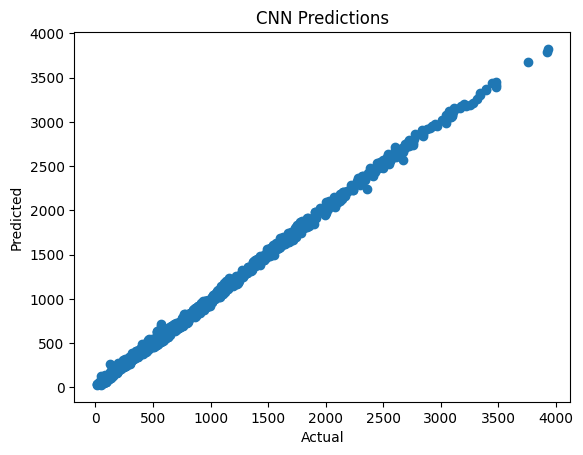

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten

# Reshape data
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN

cnn = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),  

    Conv1D(64, kernel_size=2, activation='relu'),
    Conv1D(32, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

# Predict
y_pred_cnn = cnn.predict(X_test_cnn)

# Evaluation
print("CNN MSE:", mean_squared_error(y_test, y_pred_cnn))
print("CNN MAE:", mean_absolute_error(y_test, y_pred_cnn))

# Plot Loss
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title("CNN Loss Curve")
plt.legend()
plt.show()

# Actual vs Predicted
plt.scatter(y_test, y_pred_cnn)
plt.title("CNN Predictions")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1064493.5000 - mae: 780.7569 - val_loss: 658612.6250 - val_mae: 629.8857
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 660929.6250 - mae: 627.3715 - val_loss: 575153.7500 - val_mae: 621.9631
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 552511.9375 - mae: 576.4636 - val_loss: 520984.6875 - val_mae: 536.1530
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 525742.1250 - mae: 555.3118 - val_loss: 500222.4688 - val_mae: 513.0620
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 450095.4375 - mae: 517.3151 - val_loss: 407284.5938 - val_mae: 530.5298
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 389519.0938 - mae: 485.6133 - val_loss: 369956.5312 - val_mae: 447.7100
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 366501.6875 - mae: 457.7241 - val_loss: 346593.4375 - val_mae: 425.0986
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 308129.

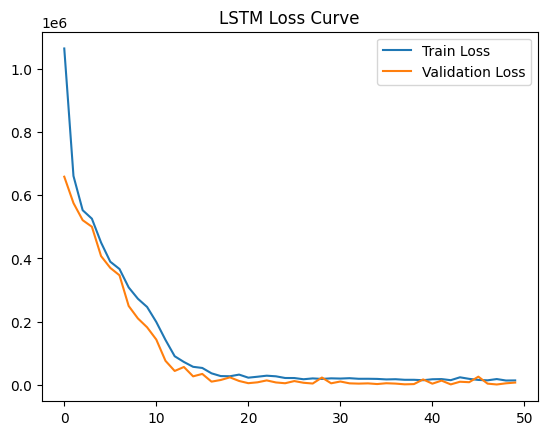

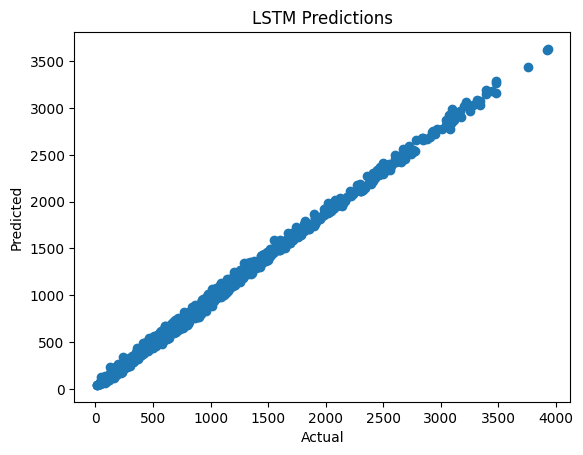

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Reshape data
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build LSTM
lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)),   # ✅ correct

    LSTM(100, activation='relu'),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history_lstm = lstm.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

# Predict
y_pred_lstm = lstm.predict(X_test_lstm)

# Evaluation
print("LSTM MSE:", mean_squared_error(y_test, y_pred_lstm))
print("LSTM MAE:", mean_absolute_error(y_test, y_pred_lstm))

# Plot Loss
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Loss Curve")
plt.legend()
plt.show()

# Actual vs Predicted
plt.scatter(y_test, y_pred_lstm)
plt.title("LSTM Predictions")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()